In [1]:
# %pip install -r requirements.txt

In [1]:
import pandas as pd

# for plotting missingness pattern
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read in data
postop_raw = pd.read_csv("Data/patient_post_op_complications.csv")
info_raw = pd.read_csv("Data/patient_information.csv")
labs_raw = pd.read_csv("Data/patient_labs.csv")

# Data Cleaning

1. Select relevant variables from each dataset
2. Remove `LOG_ID` values that correspond to multiple `MRN` values
3. Clean patient information (demographics) data
4. Merge data using `LOG_ID` and `MRN` (merge after cleaning and filtering, otherwise the dataset is too large to process that the kernel will die...)

## 1 - Select relevant variables

In [3]:
# postoperative complications
postop_raw = postop_raw[["LOG_ID", "MRN", "SMRTDTA_ELEM_VALUE"]]

# patient information
info_raw = info_raw[["LOG_ID", "MRN", "BIRTH_DATE", "HEIGHT", 
                        "WEIGHT", "SEX", "AN_START_DATETIME"]]

# labs
labs_raw = labs_raw[["LOG_ID", "MRN", "Lab Code", "Lab Name", "Observation Value", 
                 "Measurement Units", "Collection Datetime"]]

In [4]:
postop_raw.info()
info_raw.info()
labs_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203945 entries, 0 to 203944
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   LOG_ID              203945 non-null  object
 1   MRN                 203945 non-null  object
 2   SMRTDTA_ELEM_VALUE  6741 non-null    object
dtypes: object(3)
memory usage: 4.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65728 entries, 0 to 65727
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LOG_ID             65728 non-null  object 
 1   MRN                65728 non-null  object 
 2   BIRTH_DATE         65728 non-null  int64  
 3   HEIGHT             52695 non-null  object 
 4   WEIGHT             63319 non-null  float64
 5   SEX                65728 non-null  object 
 6   AN_START_DATETIME  58244 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 3.5+ MB
<cl

## 2 - Remove `LOG_ID` that corresponds to multiple `MRN`

### Postoperative complications data

In [5]:
# Group by log id and count MRN
log_mrn_count = postop_raw.groupby("LOG_ID")["MRN"].nunique()

# identify log ids with multiple MRN
ids_to_remove = log_mrn_count[log_mrn_count > 1].index 

# remove invalid log ids
# .copy().reset_index() to make sure it is a df and have continuous index
postop = postop_raw[~postop_raw["LOG_ID"].isin(ids_to_remove)].copy().reset_index()

# check the the number of unique LOG_IDs after removing the invalid ids.
postop["LOG_ID"].nunique() 

64212

In [6]:
# sanity check
postop.groupby("LOG_ID")["MRN"].nunique().max()

np.int64(1)

### Patient information data

In [16]:
log_mrn_count = info_raw.groupby("LOG_ID")["MRN"].nunique()
ids_to_remove = log_mrn_count[log_mrn_count > 1].index # identify log ids with multiple MRN
information = info_raw[~info_raw["LOG_ID"].isin(ids_to_remove)].copy().reset_index() # remove invalid log ids
information["LOG_ID"].nunique() 

64350

In [8]:
info_raw["LOG_ID"].nunique()

64354

In [9]:
# sanity check
information.groupby("LOG_ID")["MRN"].nunique().max()

np.int64(1)

### Patient labs data

In [10]:
log_mrn_count = labs_raw.groupby("LOG_ID")["MRN"].nunique()
ids_to_remove = log_mrn_count[log_mrn_count > 1].index # identify log ids with multiple MRN
labs = labs_raw[~labs_raw["LOG_ID"].isin(ids_to_remove)].copy().reset_index() # remove invalid log ids
labs["LOG_ID"].nunique() 

56123

In [11]:
labs_raw["LOG_ID"].nunique()

56125

In [12]:
# sanity check
labs.groupby("LOG_ID")["MRN"].nunique().max()

np.int64(1)

In [ ]:
# merge postop with information
patients_full = postop.merge(information, on = ["LOG_ID", "MRN"], how = "inner")

# merge with labs
patients_full = patients_full.merge(labs, on = ["LOG_ID", "MRN"], how = "inner")

### 3 - Patient Demographics

1. Rename `BIRTH_DATE` to `AGE` for clarity
2. Address missing values
    1. Fill in `HEIGHT` and `WEIGHT`
    2. Drop missings in `AN_START_TIME`

### Rename `BIRTH_DATE`

In [20]:
information.rename(columns = {"BIRTH_DATE": "AGE"}, inplace = True)

In [21]:
information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65720 entries, 0 to 65719
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              65720 non-null  int64  
 1   LOG_ID             65720 non-null  object 
 2   MRN                65720 non-null  object 
 3   AGE                65720 non-null  int64  
 4   HEIGHT             52687 non-null  object 
 5   WEIGHT             63311 non-null  float64
 6   SEX                65720 non-null  object 
 7   AN_START_DATETIME  58238 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 4.0+ MB


### Address missing values

Based on the missingness pattern plot, missing values in `HEIGHT` and `WEIGHT` appears to be MAR or MCAR (does not appear to be MNAR because there's no "blocks" of gaps). The proposed imputation methods appear reasonable.

We'll drop rows with missing anesthesia start time.

<Figure size 1200x800 with 0 Axes>

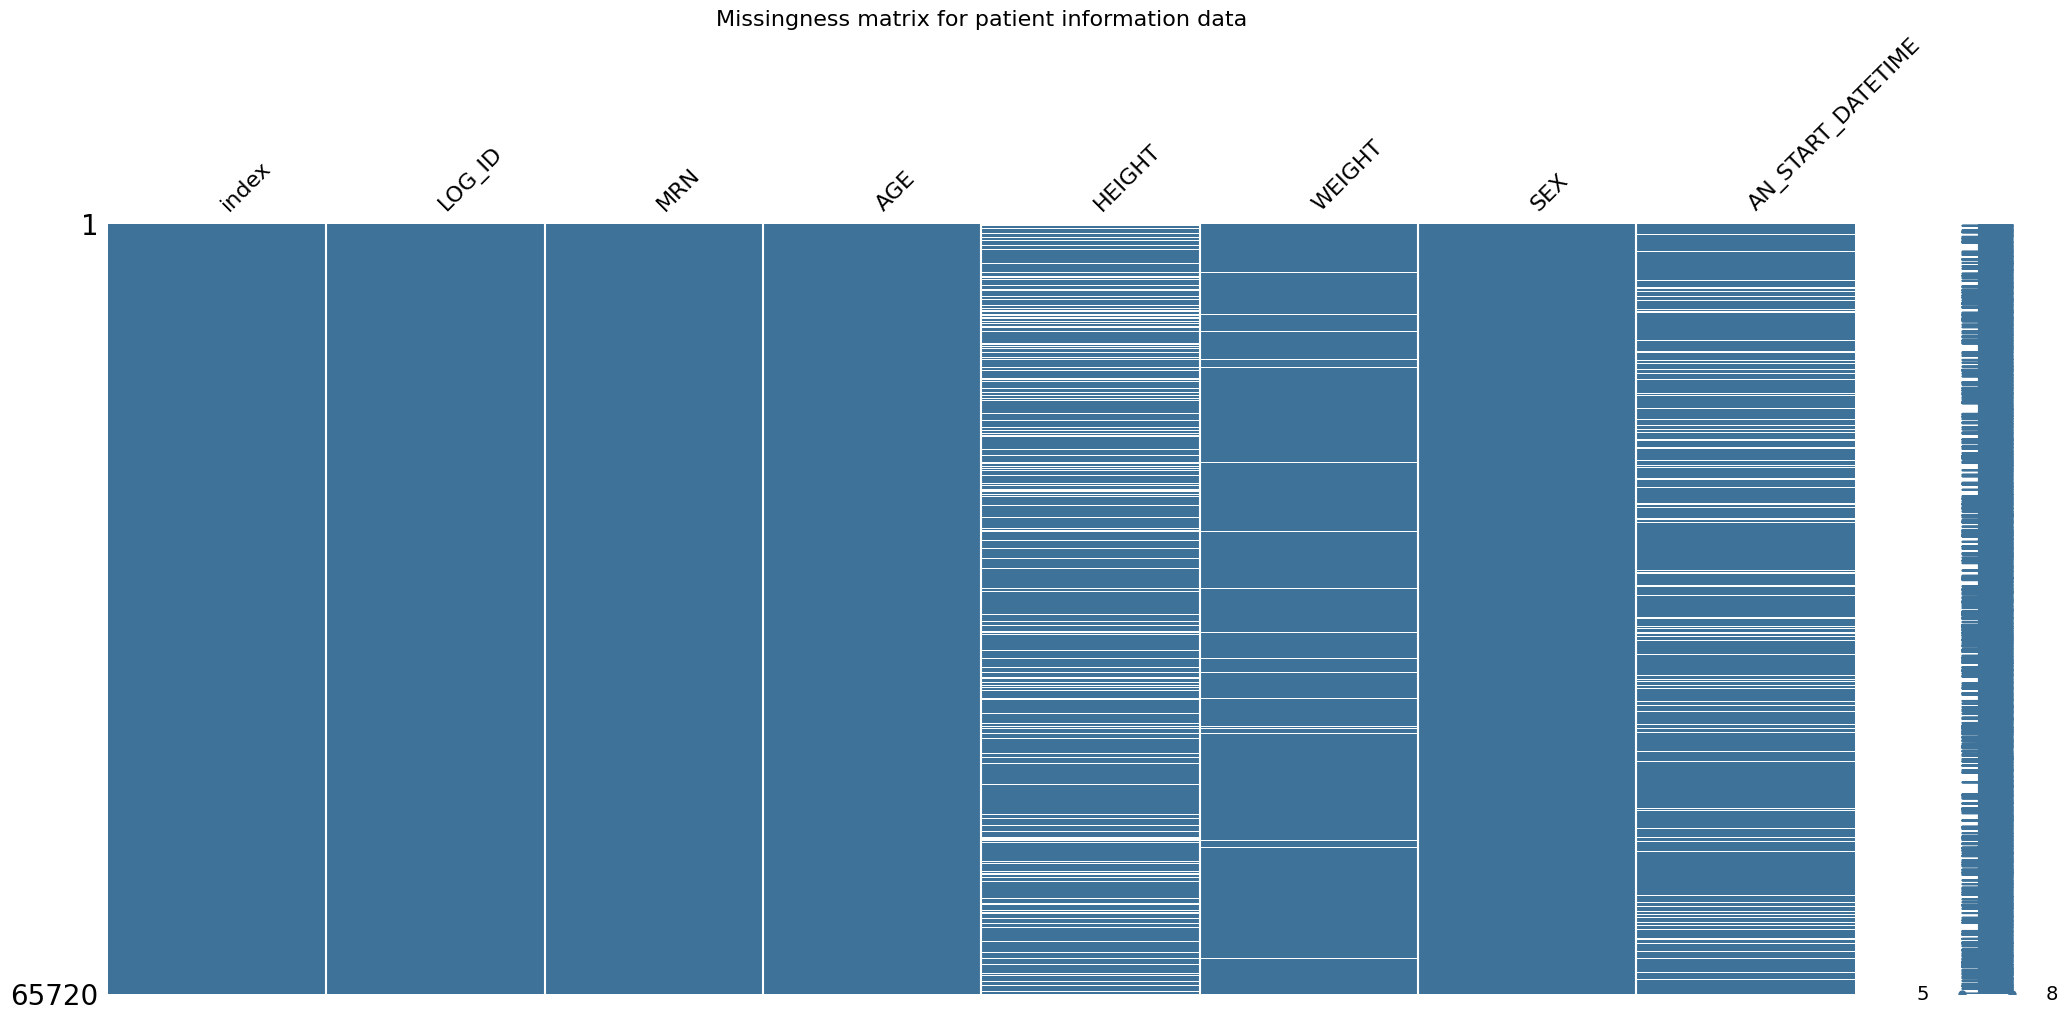

In [22]:
# visualize missing pattern
plt.figure(figsize=(12, 8))

# filter=top/bottom can help if you have 50+ columns
msno.matrix(information, sparkline = True, color = (0.25, 0.45, 0.6)) 
plt.title("Missingness matrix for patient information data", fontsize=16)
plt.show()

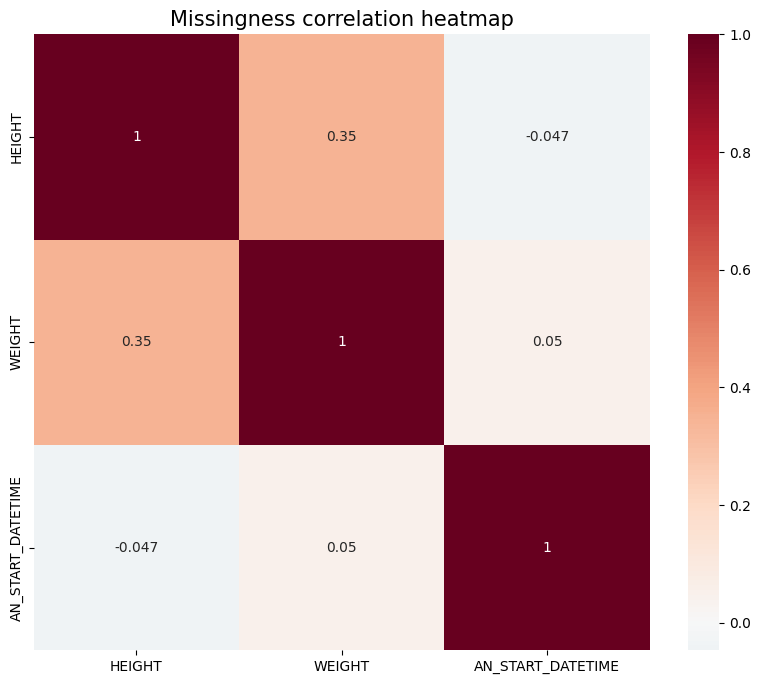

In [31]:
# Correlation heatmap
# only cols that has missings
plt.figure(figsize=(10, 8))

# identify columns with missing values
cols_with_missing = information.columns[information.isnull().any()]

# create correlation matrix for missing values
missing_cor = information[cols_with_missing].isnull().corr()

# heatmap
sns.heatmap(missing_cor, 
            annot=True,          # Shows the correlation numbers
            cmap='RdBu_r',       # Red/Blue color scheme (standard for correlations)
            center=0,            # Ensures 0 is the neutral color
            square=True)         # Forces the cells to be square

plt.title("Missingness correlation heatmap", fontsize=15)
plt.show()

In [18]:
# drop missings in AN_START_DATETIME
information = information.dropna(subset = ["AN_START_DATETIME"]).reset_index()
information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58238 entries, 0 to 58237
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   level_0            58238 non-null  int64  
 1   index              58238 non-null  int64  
 2   LOG_ID             58238 non-null  object 
 3   MRN                58238 non-null  object 
 4   BIRTH_DATE         58238 non-null  int64  
 5   HEIGHT             46301 non-null  object 
 6   WEIGHT             56300 non-null  float64
 7   SEX                58238 non-null  object 
 8   AN_START_DATETIME  58238 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 4.0+ MB
